# **Exploratory Data Analysis**

- **SNP (Single Nucleotide Polymorphism): a posição no cromosso em que pelo menos um isolado apresenta mutação. Será cada linha do arquivo vcf.**

## **1. Imports**

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import pyarrow

from pathlib import Path
from src.parsing.parsing import get_clades, get_sample_meta


## **2. Load data**

In [3]:
data_path = Path.cwd().parent / 'data' / 'raw' / 'parsnp.ggr.vcf'

with open(data_path) as f:
    for i, line in enumerate(f):
        if line.lstrip('"').startswith('#CHROM'):
            header = line.strip().strip('"').split('\t')
            header_idx = i
            break

df = pd.read_csv(data_path, sep='\t', skiprows=range(header_idx + 1), names=header, low_memory=False)

In [4]:
df.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,GCF003013715_1_B11220_Japan_2009_CLII.fasta.ref,...,GCA902712145_3_Cau1916_Hong_Kong_2019_CLI.fasta,GCA016809505_1_IFRC2087_Iran_2018_CLV.fasta,GCA003014415_1_B11243_Venezuela_2013_IV.fasta,GCA030581515_1_CBS10913_USA_2016_CLII.fasta,GCA902712175_3_Cau1912_Hong_Kong_2019_CLI.fasta,GCA902703455_1_CA13_Saudi_Arabia_2019_CLI.fasta,GCA019039435_1_CA22LBN_Lebanon_2021_CLI.fasta,GCA008275145_1_B11245_Venezuela_2012_CLIV.fasta,GCA902712215_3_Cau1909_Hong_Kong_2019_CLI.fasta,GCA902712235_3_Cau1908_Hong_Kong_2019_CLI.fasta
0,NC_072812.1,10742,TGTCGCTTGT.GGCTTCTTTA,G,A,40,PASS,NaN,GT,0,...,0,0,1,0,0,0,0,1,0,0
1,NC_072812.1,10751,TGGCTTCTTT.AATAGGCACC,A,G,40,PASS,NaN,GT,0,...,0,1,0,0,0,0,0,0,0,0
2,NC_072812.1,10784,TTGTGCCCGG.ATTTTTGGCT,A,G,40,PASS,NaN,GT,0,...,1,1,1,0,1,1,1,1,1,1
3,NC_072812.1,10802,CTCTTTACGA.AATGTGCTTG,A,G,40,PASS,NaN,GT,0,...,0,0,1,0,0,0,0,1,0,0
4,NC_072812.1,10820,TGTACGTACG.CAAGCAAGAC,C,T,40,PASS,NaN,GT,0,...,0,1,0,0,0,0,0,0,0,0


In [5]:
df.iloc[:, :9]

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT
0,NC_072812.1,10742,TGTCGCTTGT.GGCTTCTTTA,G,A,40,PASS,NaN,GT
1,NC_072812.1,10751,TGGCTTCTTT.AATAGGCACC,A,G,40,PASS,NaN,GT
2,NC_072812.1,10784,TTGTGCCCGG.ATTTTTGGCT,A,G,40,PASS,NaN,GT
3,NC_072812.1,10802,CTCTTTACGA.AATGTGCTTG,A,G,40,PASS,NaN,GT
4,NC_072812.1,10820,TGTACGTACG.CAAGCAAGAC,C,T,40,PASS,NaN,GT
...,...,...,...,...,...,...,...,...,...
309691,NC_072818.1,875532,GTTTTTCGAC.AAACTTTGGC,A,G,40,PASS,NaN,GT
309692,NC_072818.1,875533,TTTTTCGACA.AACTTTGGCC,A,G,40,PASS,NaN,GT
309693,NC_072818.1,875534,TTTTCGACAA.ACTTTGGCCT,A,"C,T",40,PASS,NaN,GT
309694,NC_072818.1,875539,GACAAACTTT.GGCCTTCTTT,G,A,40,PASS,NaN,GT


In [6]:
print(f'Colunas de Metadados {list(df.iloc[:, :9].columns)}')
print('')
print(f'As colunas remanescentes representam isolados/amostras do fungo. Por exemplo: {df.iloc[:, 10].name}')

Colunas de Metadados ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'FORMAT']

As colunas remanescentes representam isolados/amostras do fungo. Por exemplo: GCA014638885_1_FG_GE5_Italy_2020_CLI.fasta


## **3. Data Preparation**

### **3.1 Normalize Categorical Columns**

In [7]:
cat_cols = list(df.dtypes[df.dtypes == 'str'].index)
cat_cols

['#CHROM', 'ID', 'REF', 'ALT', 'FILTER', 'FORMAT']

In [8]:
# Lower column names
df.columns = df.columns.str.lower()

# List of lowered categorical columns
cat_cols = list(df.dtypes[df.dtypes == 'str'].index)

for col in cat_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df.rename(columns={'#chrom': 'chrom'}, inplace=True)


In [9]:
df.head()

,chrom,pos,id,ref,alt,qual,filter,info,format,gcf003013715_1_b11220_japan_2009_clii.fasta.ref,...,gca902712145_3_cau1916_hong_kong_2019_cli.fasta,gca016809505_1_ifrc2087_iran_2018_clv.fasta,gca003014415_1_b11243_venezuela_2013_iv.fasta,gca030581515_1_cbs10913_usa_2016_clii.fasta,gca902712175_3_cau1912_hong_kong_2019_cli.fasta,gca902703455_1_ca13_saudi_arabia_2019_cli.fasta,gca019039435_1_ca22lbn_lebanon_2021_cli.fasta,gca008275145_1_b11245_venezuela_2012_cliv.fasta,gca902712215_3_cau1909_hong_kong_2019_cli.fasta,gca902712235_3_cau1908_hong_kong_2019_cli.fasta
0,nc_072812.1,10742,tgtcgcttgt.ggcttcttta,g,a,40,pass,NaN,gt,0,...,0,0,1,0,0,0,0,1,0,0
1,nc_072812.1,10751,tggcttcttt.aataggcacc,a,g,40,pass,NaN,gt,0,...,0,1,0,0,0,0,0,0,0,0
2,nc_072812.1,10784,ttgtgcccgg.atttttggct,a,g,40,pass,NaN,gt,0,...,1,1,1,0,1,1,1,1,1,1
3,nc_072812.1,10802,ctctttacga.aatgtgcttg,a,g,40,pass,NaN,gt,0,...,0,0,1,0,0,0,0,1,0,0
4,nc_072812.1,10820,tgtacgtacg.caagcaagac,c,t,40,pass,NaN,gt,0,...,0,1,0,0,0,0,0,0,0,0


### **3.2 Missing Values**

In [10]:
df.columns[df.isnull().any()].tolist()

['info']

Apenas a coluna `info` possui `NaN's` e podemos removê-la sem prejuízo:

In [11]:
del df['info']

### **3.3 DataFrame with Valid SNP'S**

Aqui apenas os dados cujo `filter=pass` serão selecionados, os quais estabelecem as SNP's válidas:

In [12]:
pass_df = df[df['filter'] == 'pass']
pass_df

,chrom,pos,id,ref,alt,qual,filter,format,gcf003013715_1_b11220_japan_2009_clii.fasta.ref,gca014638885_1_fg_ge5_italy_2020_cli.fasta,...,gca902712145_3_cau1916_hong_kong_2019_cli.fasta,gca016809505_1_ifrc2087_iran_2018_clv.fasta,gca003014415_1_b11243_venezuela_2013_iv.fasta,gca030581515_1_cbs10913_usa_2016_clii.fasta,gca902712175_3_cau1912_hong_kong_2019_cli.fasta,gca902703455_1_ca13_saudi_arabia_2019_cli.fasta,gca019039435_1_ca22lbn_lebanon_2021_cli.fasta,gca008275145_1_b11245_venezuela_2012_cliv.fasta,gca902712215_3_cau1909_hong_kong_2019_cli.fasta,gca902712235_3_cau1908_hong_kong_2019_cli.fasta
0,nc_072812.1,10742,tgtcgcttgt.ggcttcttta,g,a,40,pass,gt,0,0,...,0,0,1,0,0,0,0,1,0,0
1,nc_072812.1,10751,tggcttcttt.aataggcacc,a,g,40,pass,gt,0,0,...,0,1,0,0,0,0,0,0,0,0
2,nc_072812.1,10784,ttgtgcccgg.atttttggct,a,g,40,pass,gt,0,1,...,1,1,1,0,1,1,1,1,1,1
3,nc_072812.1,10802,ctctttacga.aatgtgcttg,a,g,40,pass,gt,0,0,...,0,0,1,0,0,0,0,1,0,0
4,nc_072812.1,10820,tgtacgtacg.caagcaagac,c,t,40,pass,gt,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309691,nc_072818.1,875532,gtttttcgac.aaactttggc,a,g,40,pass,gt,0,1,...,1,0,0,0,1,1,1,0,1,1
309692,nc_072818.1,875533,tttttcgaca.aactttggcc,a,g,40,pass,gt,0,0,...,0,0,0,0,0,0,0,0,0,0
309693,nc_072818.1,875534,ttttcgacaa.actttggcct,a,"c,t",40,pass,gt,0,1,...,1,0,0,0,1,1,1,0,1,1
309694,nc_072818.1,875539,gacaaacttt.ggccttcttt,g,a,40,pass,gt,0,0,...,0,1,0,0,0,0,0,0,0,0


### **3.4 Genotype Data**

Cada coluna rotulada por um isolado representa medidas do genótipo deste, enquanto que cada linha correspondente irá estabelecer a posição em seu cromossomo cuja mutação pode ou não ter ocorrido. Trata-se portanto de uma coluna categórica com os possíveis valores:

- **0: Não houve mutação;**
- **1: Houve mutação na primeira base estabelecida na coluna `alt`;**
- **2: Houve mutação na segunda base estabelecida em `alt`.**

In [13]:
gt_df = pass_df.iloc[:, 8:]
gt_df

,gcf003013715_1_b11220_japan_2009_clii.fasta.ref,gca014638885_1_fg_ge5_italy_2020_cli.fasta,558.pilon.fasta,gca902712185_3_cau1917_hong_kong_2019_cli.fasta,gca019039715_1_ca6lbn_lebanon_2020_cli.fasta,gca031359945_2_b11103_pakistan_2015_cli.fasta,593.pilon.fasta,gca902703515_1_ca15_saudi_arabia_cli.fasta,gca019039775_1_ca2lbn_lebanon_2020_cli.fasta,gca007168705_1_jcm15448_2005_clii.fasta,...,gca902712145_3_cau1916_hong_kong_2019_cli.fasta,gca016809505_1_ifrc2087_iran_2018_clv.fasta,gca003014415_1_b11243_venezuela_2013_iv.fasta,gca030581515_1_cbs10913_usa_2016_clii.fasta,gca902712175_3_cau1912_hong_kong_2019_cli.fasta,gca902703455_1_ca13_saudi_arabia_2019_cli.fasta,gca019039435_1_ca22lbn_lebanon_2021_cli.fasta,gca008275145_1_b11245_venezuela_2012_cliv.fasta,gca902712215_3_cau1909_hong_kong_2019_cli.fasta,gca902712235_3_cau1908_hong_kong_2019_cli.fasta
0,0,0,1,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,1,1,1,1,1,1,1,1,0,...,1,1,1,0,1,1,1,1,1,1
3,0,0,1,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309691,0,1,0,1,1,1,0,1,1,0,...,1,0,0,0,1,1,1,0,1,1
309692,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
309693,0,1,0,1,1,1,0,1,1,0,...,1,0,0,0,1,1,1,0,1,1
309694,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [14]:
print(f'Os dados de genótipo possuem {gt_df.shape[0]} SNPs válidas e {gt_df.shape[1]} amostras/isolados.')

Os dados de genótipo possuem 272578 SNPs válidas e 153 amostras/isolados.


Transpondo a "matriz" de genótipos dos isolados, cada coluna é uma leitura binária do tipo: "Numa dada posição o isolado sofreu mutação ou não?". Em outras palavras, cada coluna é uma SNP e cada linha uma amostra/isolado.

In [15]:
gt_df = gt_df.T
gt_df

,0,1,2,3,4,5,6,7,8,9,...,309686,309687,309688,309689,309690,309691,309692,309693,309694,309695
gcf003013715_1_b11220_japan_2009_clii.fasta.ref,0,0,0,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
gca014638885_1_fg_ge5_italy_2020_cli.fasta,0,0,1,0,0,2,1,0,1,0,...,1,1,1,1,0,1,0,1,0,0
558.pilon.fasta,1,0,1,1,0,1,2,1,1,1,...,1,1,1,0,0,0,0,0,0,0
gca902712185_3_cau1917_hong_kong_2019_cli.fasta,0,0,1,0,0,2,1,0,1,0,...,1,1,1,1,0,1,0,1,0,0
gca019039715_1_ca6lbn_lebanon_2020_cli.fasta,0,0,1,0,0,2,1,0,1,0,...,1,1,1,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gca902703455_1_ca13_saudi_arabia_2019_cli.fasta,0,0,1,0,0,2,1,0,1,0,...,1,1,1,1,0,1,0,1,0,0
gca019039435_1_ca22lbn_lebanon_2021_cli.fasta,0,0,1,0,0,2,1,0,1,0,...,1,1,1,1,0,1,0,1,0,0
gca008275145_1_b11245_venezuela_2012_cliv.fasta,1,0,1,1,0,1,2,1,1,1,...,1,1,1,0,0,0,0,0,0,0
gca902712215_3_cau1909_hong_kong_2019_cli.fasta,0,0,1,0,0,2,1,0,1,0,...,1,1,1,1,0,1,0,1,0,0


### **3.5 Parsing metadata**

Os nomes das amostras carregam as seguintes informações relevantes:

- **País: origem geográfica do isolado;**
- **Ano: qual ano a amostra foi colhida;**
- **Clado: grupo evolutivo cujo isolado pertence.**

Nesta seção iremos extrair e armazenas essas informações para posteriormente verificarmos as origens biológicas dos clusters.

#### **3.5.1 Extract Clade Labels**

In [16]:
clades = get_clades(df, gt_df)
print(f'A lista contém {len(clades)} clados; um para cada isolado/amostra.')

A lista contém 153 clados; um para cada isolado/amostra.


In [17]:
# Add clades column
gt_df['clade'] = clades

gt_df['clade'].value_counts()

clade
I      112
III     13
MG       8
IV       8
II       7
VI       3
V        1
Name: count, dtype: int64

Após o "parseamento", podemos verificar se alguma amostra ficou sem clado:

In [18]:
gt_df[gt_df.clade.isna() == True]

,0,1,2,3,4,5,6,7,8,9,...,309687,309688,309689,309690,309691,309692,309693,309694,309695,clade
gca019039535_1_ca17lbn_lebanon_2021_ca17lbn.fasta,0,0,1,0,0,2,1,0,1,0,...,1,1,1,0,1,0,1,0,0,NaN


Apenas a amostra `gca019039535_1_ca17lbn_lebanon_2021_ca17lbn.fasta` não segue a nomenclatura das demais, com sufixo `CL_` precedendo o clado. Portanto, baseado no artigo e na consistência com todos demais isolados do Líbano, feremos a atribuição manualmente:

In [19]:
gt_df[gt_df.index.str.contains('lbn')]['clade'].value_counts()

clade
I    27
Name: count, dtype: int64

In [20]:
gt_df.loc['gca019039535_1_ca17lbn_lebanon_2021_ca17lbn.fasta', 'clade'] = 'I'

In [21]:
gt_df['clade'].isna().sum()

np.int64(0)

#### **3.5.3 Extract Country & Year**

In [22]:
sample_meta_df = get_sample_meta(gt_df)
sample_meta_df

,clade,country,year
gcf003013715_1_b11220_japan_2009_clii.fasta.ref,II,japan,2009.0
gca014638885_1_fg_ge5_italy_2020_cli.fasta,I,italy,2020.0
558.pilon.fasta,MG,NaN,NaN
gca902712185_3_cau1917_hong_kong_2019_cli.fasta,I,hong_kong,2019.0
gca019039715_1_ca6lbn_lebanon_2020_cli.fasta,I,lebanon,2020.0
...,...,...,...
gca902703455_1_ca13_saudi_arabia_2019_cli.fasta,I,saudi_arabia,2019.0
gca019039435_1_ca22lbn_lebanon_2021_cli.fasta,I,lebanon,2021.0
gca008275145_1_b11245_venezuela_2012_cliv.fasta,IV,venezuela,2012.0
gca902712215_3_cau1909_hong_kong_2019_cli.fasta,I,hong_kong,2019.0


In [23]:
sample_meta_df[(sample_meta_df['country'].isna()) & (sample_meta_df['clade'] != 'MG')]

,clade,country,year
gca007168705_1_jcm15448_2005_clii.fasta,II,NaN,2005.0
gca032715285_1_f3485_2023_clvi.fasta,VI,NaN,2023.0
gca032367535_1_f0083_2018_clvi.fasta,VI,NaN,2018.0
gca947395165_1_16b25_cli.fasta,I,NaN,NaN
gca031463115_1_470140_2016_cli.fasta,I,NaN,2016.0
gca032714025_1_f1580_2022_clvi.fasta,VI,NaN,2022.0
gca019039535_1_ca17lbn_lebanon_2021_ca17lbn.fasta,I,NaN,2021.0
gca020809265_1_l1537_2020_cli.fasta,I,NaN,2020.0


In [24]:
sample_meta_df[(sample_meta_df['year'].isna()) & (sample_meta_df['clade'] != 'MG')]

,clade,country,year
gca902703515_1_ca15_saudi_arabia_cli.fasta,I,saudi_arabia,NaN
gca016772195_1_b12631_usa_cliii.fasta,III,usa,NaN
gca902703685_1_ca23_saudi_arabia_cli.fasta,I,saudi_arabia,NaN
gca008729255_1_394_2_germany_cli.fasta,I,germany,NaN
gca032888605_1_ca01_china_cli.fasta,I,china,NaN
gca027563765_1_i172_israel_cliv.fasta,IV,israel,NaN
gca947395165_1_16b25_cli.fasta,I,NaN,NaN
gca902703485_1_ca11_saudi_arabia_cli.fasta,I,saudi_arabia,NaN
gca016495645_1_b12043_usa_clii.fasta,II,usa,NaN
gca008729195_1_394_1_germany_cli_.fasta,I,germany,NaN


In [25]:
sample_meta_df.isna().sum()

clade       0
country    16
year       22
dtype: int64

Claramente alguns metadados estão faltando, mas podemos corrigir manualmente alguns desses valores, principalmente aqueles com clado = 'MG':

In [26]:
# correção manual: ca17lbn segue o padrão dos outros isolados libaneses
sample_meta_df.loc['gca019039535_1_ca17lbn_lebanon_2021_ca17lbn.fasta', 'country'] = 'lebanon'
sample_meta_df.loc['gca019039535_1_ca17lbn_lebanon_2021_ca17lbn.fasta', 'year'] = 2021

# jcm15448: isolado original japonês, identificado externamente
sample_meta_df.loc['gca007168705_1_jcm15448_2005_clii.fasta', 'country'] = 'japan'

# isolados MG: Minas Gerais, Brasil, 2024
mg_mask = sample_meta_df['clade'] == 'MG'
sample_meta_df.loc[mg_mask, 'country'] = 'brazil'
sample_meta_df.loc[mg_mask, 'year'] = 2024

In [27]:
sample_meta_df.isna().sum()

clade       0
country     6
year       14
dtype: int64

Em suma, devido a  ausência de maiores informações à respeito desses metadados, prosseguimos com os valores **NaN's**. 

### **3.6 Data Matrix**

In [28]:
# Labels
y = gt_df['clade'].values

# Feature matrix
X = gt_df.drop('clade', axis=1).values

## **4. Data Visualization**

### **4.1 Samples x Clade**

In [29]:
clade_counts = y.value_counts()

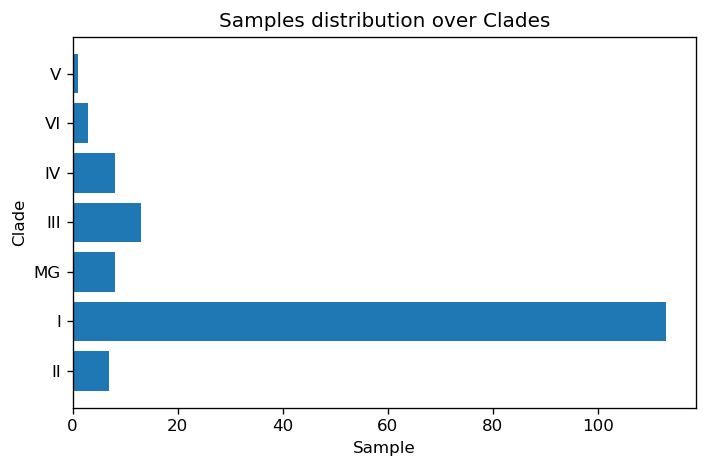

In [30]:
fig, ax = plt.subplots(figsize=(6,4), dpi=120)

ax.barh(clade_counts.index, clade_counts.values)

ax.set(
    title='Samples distribution over Clades',
    xlabel='Sample',
    ylabel='Clade'
)

fig.tight_layout()
plt.show()

### **4.2 SNPS X Chromosomes**

In [31]:
chroms_counts = pass_df['chrom'].value_counts()
chroms_counts

chrom
nc_072812.1    66461
nc_072813.1    58080
nc_072814.1    52366
nc_072815.1    31081
nc_072818.1    23625
nc_072816.1    21910
nc_072817.1    19055
Name: count, dtype: int64

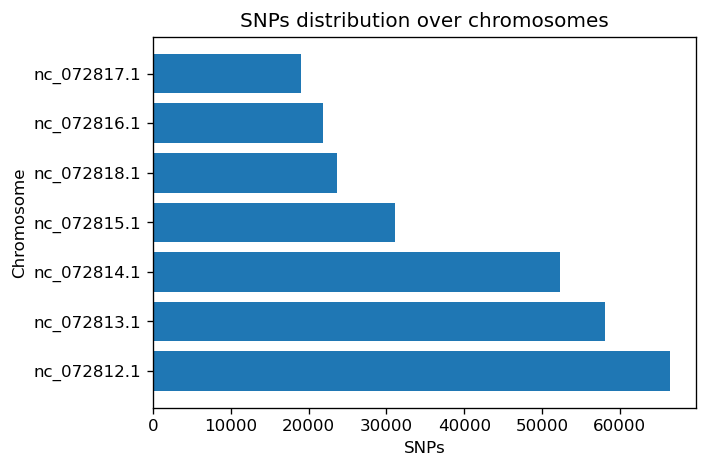

In [32]:
fig, ax = plt.subplots(figsize=(6,4), dpi=120)

ax.barh(chroms_counts.index, chroms_counts.values)
ax.set(
    title='SNPs distribution over chromosomes',
    xlabel='SNPs',
    ylabel='Chromosome')

fig.tight_layout()
plt.show()

## **Saving Data**

In [33]:
# Save genotype matrix
gt_df.drop(columns='clade').to_parquet('../data/processed/X_genotypes.parquet')

# Save clade labels
pd.Series(gt_df.clade.values, name='clade').to_csv('../data/processed/y_clades.csv', index=False)

In [34]:
snp_info = pass_df[['chrom', 'pos']].reset_index(drop=True)
snp_info.to_csv('../data/processed/snp_info.csv', index=False)

In [56]:
pass_df[(pass_df['ref'] == 'g') & (pass_df['alt'] == 'c,a') & (pass_df['pos'] == 1105307)].iloc[:, 9:].T.value_counts()

102127
0         133
2          18
1           1
Name: count, dtype: int64

In [53]:
133 + 18 + 1

152

In [38]:
transition_info = pass_df[['ref', 'alt']]
transition_info.to_csv('../data/processed/transition_info.csv', index=False)

In [36]:
sample_meta_df.to_csv('../data/processed/sample_meta.csv')

## **Resumo**

O arquivo VCF contém 272.578 SNPs filtrados por qualidade, distribuídos ao longo de 7 cromossomos, provenientes de 153 isolados de *C. auris*. O Clado I domina o dataset com 113 amostras, enquanto os Clados V e VI são representados por apenas 1 e 3 isolados, respectivamente. A matriz de genótipos (153 amostras × 272.578 SNPs) está pronta para redução de dimensionalidade via PCA.